In [9]:
from astropy.table import Table 
import numpy as np

# load data onto an astropy table
jades_path = '/home/caltech-msanche3/data/JADES_south_fits_data.fits'
jades_data = Table.read(jades_path, hdu='CIRC_BSUB',format='fits')
# change units of flux from nJy to microJy so eazy fits correctly
print(jades_data.colnames)
for col in jades_data.colnames:
    if '_CIRC2' in col or '_ei' in col:
        jades_data[col] = jades_data[col] * 0.001
redshift = Table.read(jades_path, hdu='PHOTOZ_KRON',format='fits')


['ID', 'RA', 'DEC', 'F070W_CIRC0', 'F070W_CIRC0_bkg', 'F070W_CIRC0_e', 'F070W_CIRC0_ei', 'F070W_CIRC1', 'F070W_CIRC1_bkg', 'F070W_CIRC1_e', 'F070W_CIRC1_ei', 'F070W_CIRC2', 'F070W_CIRC2_bkg', 'F070W_CIRC2_e', 'F070W_CIRC2_ei', 'F070W_CIRC3', 'F070W_CIRC3_bkg', 'F070W_CIRC3_e', 'F070W_CIRC3_ei', 'F070W_CIRC4', 'F070W_CIRC4_bkg', 'F070W_CIRC4_e', 'F070W_CIRC4_ei', 'F070W_CIRC5', 'F070W_CIRC5_bkg', 'F070W_CIRC5_e', 'F070W_CIRC5_ei', 'F070W_CIRC6', 'F070W_CIRC6_bkg', 'F070W_CIRC6_e', 'F070W_CIRC6_ei', 'F090W_CIRC0', 'F090W_CIRC0_bkg', 'F090W_CIRC0_e', 'F090W_CIRC0_ei', 'F090W_CIRC1', 'F090W_CIRC1_bkg', 'F090W_CIRC1_e', 'F090W_CIRC1_ei', 'F090W_CIRC2', 'F090W_CIRC2_bkg', 'F090W_CIRC2_e', 'F090W_CIRC2_ei', 'F090W_CIRC3', 'F090W_CIRC3_bkg', 'F090W_CIRC3_e', 'F090W_CIRC3_ei', 'F090W_CIRC4', 'F090W_CIRC4_bkg', 'F090W_CIRC4_e', 'F090W_CIRC4_ei', 'F090W_CIRC5', 'F090W_CIRC5_bkg', 'F090W_CIRC5_e', 'F090W_CIRC5_ei', 'F090W_CIRC6', 'F090W_CIRC6_bkg', 'F090W_CIRC6_e', 'F090W_CIRC6_ei', 'F105W_CIRC0',

In [10]:
# ID 12326 is likely not correct and I will be ommiting it for the time being
# there are outliers in this list
# total objs: 14
ids = [13405,14376,27503,96216,107324,127219,131688,131971,132845,135819,165595,169896,265801,318988]
zspec = [7.95,7.96,8.19,12.48,9.68,6.63,6.33,6.32,6.09,7.04,8.58,6.16,9.43,6.04]
jades_zphot = [8.35,7.50,8.55,12.46,10.29,6.51,6.29,6.60,6.09,7.05,8.98,6.32,9.9,6.54]
mask = []
for i in range(len(jades_data)):
    if jades_data[i]['ID'] in ids:
        mask.append(True)
    else:
        mask.append(False)

new_jades_data = jades_data[mask]
#new_jades_data.add_column(zspec,name='ZSPEC',index=2)
print(new_jades_data)

  ID       RA       DEC     ... F850LP_CIRC6_e   F850LP_CIRC6_ei   
          deg       deg     ...      nJy               nJy         
------ --------- ---------- ... -------------- --------------------
 13405 53.103912 -27.890594 ...       18.65322    0.018650146484375
 14376 53.076694 -27.889568 ...      22.322878 0.022320674896240233
 27503 53.075806 -27.879381 ...      19.595543 0.019591638565063477
 96216 53.166344  -27.82156 ...      5.0580993  0.00505741548538208
107324 53.167355 -27.807512 ...      5.4513164 0.005449738025665283
127219  53.16905 -27.778833 ...       5.488443 0.005488416194915771
131688  53.13492  -27.77271 ...      32.210308  0.03219993209838867
131971   53.1666 -27.772404 ...       5.235929 0.005234539985656738
132845  53.15952 -27.771523 ...      10.175247 0.010170273780822754
135819 53.134228 -27.768917 ...      16.277985 0.016259729385375978
165595   53.0583  -27.88485 ...       25.81777 0.025802650451660157
169896 53.091164 -27.877272 ...      19.488157  

In [11]:
# code made specifically for HellBender cluster fitting
#import pandas as pd
import eazy
import os
import eazy.photoz
from astropy.io import fits
from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
from eazy import filters, utils, templates

params = {}
print("Loading parameters...")
# 1. Tell it where your data is
params['CATALOG_FILE'] = new_jades_data
#params['CATALOG_FORMAT'] = 'fits'
params['EXT_NUMBER'] = 9
params['SYS_ERR'] = 0.03
params['Z_MIN'] = 5
params['Z_MAX'] = 15
params['IGM_SCALE_TAU'] = 1.0
params['FIX_ZSPEC'] = True
#params['RENORM_TEMPLATES'] = False
params['PRIOR_ABZP'] = 23.90

# 2. Tell it what templates to use to fit the light
params['TEMPLATES_FILE'] = "/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/data/eazy-photoz/templates/fsps_full/tweak_fsps_QSF_12_v3.param"

# 3. Choose a base name for the output files it saves
# path to jades data output directory
# ^^ let's not do this for now and just name the file, we can see where it is directed to once code runs
# filtered: only fit z>6 using the redshifts provided in the JADES catalog
params['MAIN_OUTPUT_FILE'] = 'JADES_south_control_fit_circ_z'

print("Loaded parameters!")
print('Initializing fitting program...')
# initialize the fitting program
#add path to translate file
trans_file = '/home/caltech-msanche3/data/jades_trans_file_circ2.csv'
ez = eazy.photoz.PhotoZ(
    param_file=None, # don't call default file
    translate_file=trans_file, # call translate file
    zeropoint_file=None, # no zero points file for now?
    params=params, # call your own params, eazy will use default for those not defined
    load_prior=False, # uh
    load_products=False # uh
    
)
print('Fitting program initialized successfully!')


Loading parameters...
Loaded parameters!
Initializing fitting program...
Read default param file: /mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.13/site-packages/eazy/data/zphot.param.default
CATALOG_FILE is a table
   >>> NOBJ = 14
F070W_CIRC2 F070W_CIRC2_ei (362): jwst_nircam_f070w
F090W_CIRC2 F090W_CIRC2_ei (363): jwst_nircam_f090w
F105W_CIRC2 F105W_CIRC2_ei (202): hst/wfc3/IR/f105w.dat
F115W_CIRC2 F115W_CIRC2_ei (364): jwst_nircam_f115w
F125W_CIRC2 F125W_CIRC2_ei (203): hst/wfc3/IR/f125w.dat
F140W_CIRC2 F140W_CIRC2_ei (204): hst/wfc3/IR/f140w.dat
F150W_CIRC2 F150W_CIRC2_ei (365): jwst_nircam_f150w
F160W_CIRC2 F160W_CIRC2_ei (205): hst/wfc3/IR/f160w.dat
F162M_CIRC2 F162M_CIRC2_ei (369): jwst_nircam_f162m
F182M_CIRC2 F182M_CIRC2_ei (370): jwst_nircam_f182m
F200W_CIRC2 F200W_CIRC2_ei (366): jwst_nircam_f200w
F210M_CIRC2 F210M_CIRC2_ei (371): jwst_nircam_f210m
F250M_CIRC2 F250M_CIRC2_ei (379): jwst_nircam_f250m
F277W_CIRC2 F277W_CIRC2_ei (375): jwst_nircam_f277w

100%|██████████| 12/12 [00:17<00:00,  1.50s/it]


Template   0: tweak_fsps_QSF_12_v3_001.dat (NZ=1).
Template   1: tweak_fsps_QSF_12_v3_002.dat (NZ=1).
Template   2: tweak_fsps_QSF_12_v3_003.dat (NZ=1).
Template   3: tweak_fsps_QSF_12_v3_004.dat (NZ=1).
Template   4: tweak_fsps_QSF_12_v3_005.dat (NZ=1).
Template   5: tweak_fsps_QSF_12_v3_006.dat (NZ=1).
Template   6: tweak_fsps_QSF_12_v3_007.dat (NZ=1).
Template   7: tweak_fsps_QSF_12_v3_008.dat (NZ=1).
Template   8: tweak_fsps_QSF_12_v3_009.dat (NZ=1).
Template   9: tweak_fsps_QSF_12_v3_010.dat (NZ=1).
Template  10: tweak_fsps_QSF_12_v3_011.dat (NZ=1).
Template  11: tweak_fsps_QSF_12_v3_012.dat (NZ=1).
Process templates: 21.043 s


99it [00:00, 11737.13it/s]

Fitting program initialized successfully!


In [12]:
#ez.fit_catalog(ez.idx[mask],n_proc=16)

#ez.cat['z_spec'] = new_jades_data['ZSPEC']
ez.fit_catalog(ez.idx,n_proc=16)

100%|██████████| 99/99 [00:00<00:00, 4831.42it/s]

Compute best fits
fit_best: 0.0 s (n_proc=1,  NOBJ=14)
Fit 0.4 s (n_proc=16, NOBJ=14)


In [13]:
print('Generating standard output...')
# Derived parameters (z params, RF colors, masses, SFR, etc.)
zout, hdu = ez.standard_output(
    simple=False, 
    rf_pad_width=0.5,
    rf_max_err=2, 
    prior=False,
    beta_prior=False, 
    absmag_filters=[], 
    extra_rf_filters=[]
)
# 'zout' also saved to [MAIN_OUTPUT_FILE].zout.fits

print('Standard output generated successfully!')
print('All steps completed successfully!')
print('Output saved to [MAIN_OUTPUT_FILE].zout.fits')

Generating standard output...
Get best fit coeffs & best redshifts
fit_best: 0.0 s (n_proc=1,  NOBJ=14)
Get parameters (UBVJ=[153, 154, 155, 161], simple=False)


100%|██████████| 14/14 [00:00<00:00, 240.99it/s]

CALLED Tweak Templates


Standard output generated successfully!
All steps completed successfully!
Output saved to [MAIN_OUTPUT_FILE].zout.fits


<>:57: SyntaxWarning: invalid escape sequence '\c'
<>:57: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_334983/64652684.py:57: SyntaxWarning: invalid escape sequence '\c'
  ax.text(x=-13.8, y=.06, s= "$\chi^2$= " f"{output_data[ids_index[i]]['z_phot_chi2']:.1f}  " r"$z_{spec}$: " f"{zspec[i]}   " r"JADES N $z_{phot}$: " f"{jades_zphot[i]:.2f}",


[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]


/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.1/site-packages/IPython/core/events.py:100: UserWarning: AutoMinorLocator does not work on logarithmic scales
  func(*args, **kwargs)
/mnt/pixstor/data/caltech-msanche3/miniconda/envs/eazyenv2/lib/python3.1/site-packages/IPython/core/pylabtools.py:170: UserWarning: AutoMinorLocator does not work on logarithmic scales
  fig.canvas.print_figure(bytes_io, **kw)


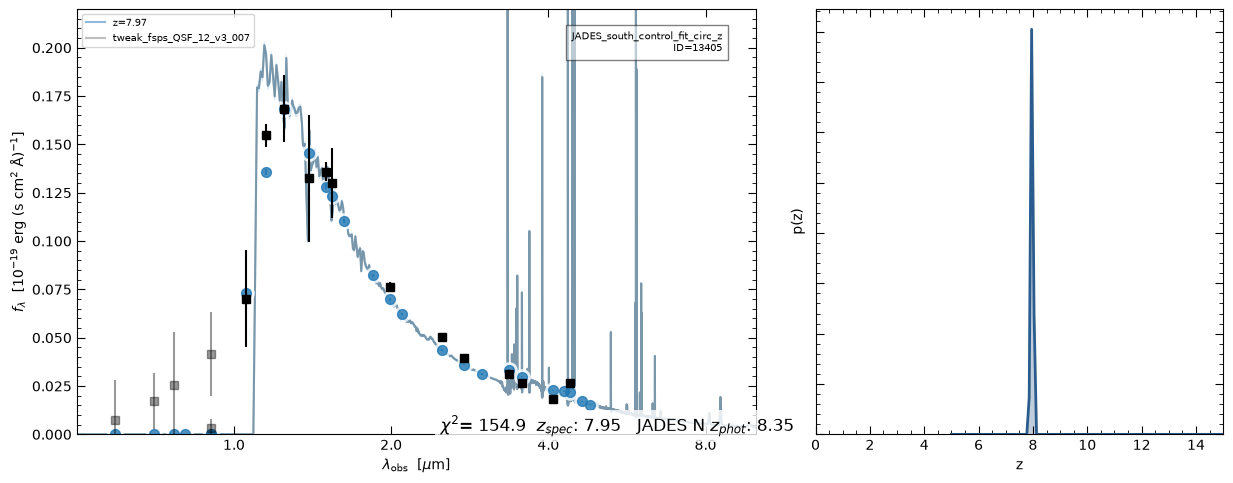

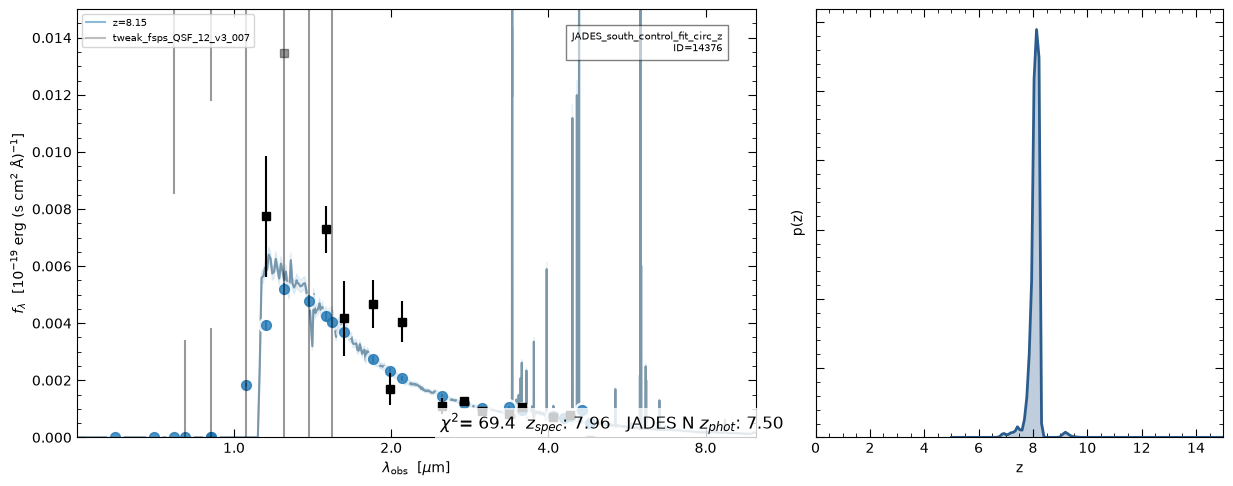

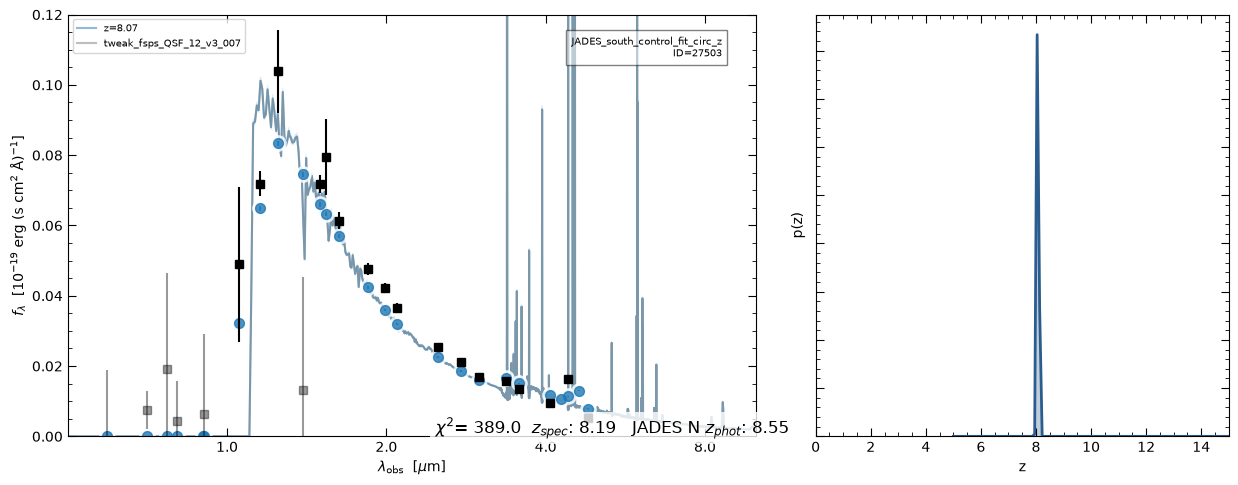

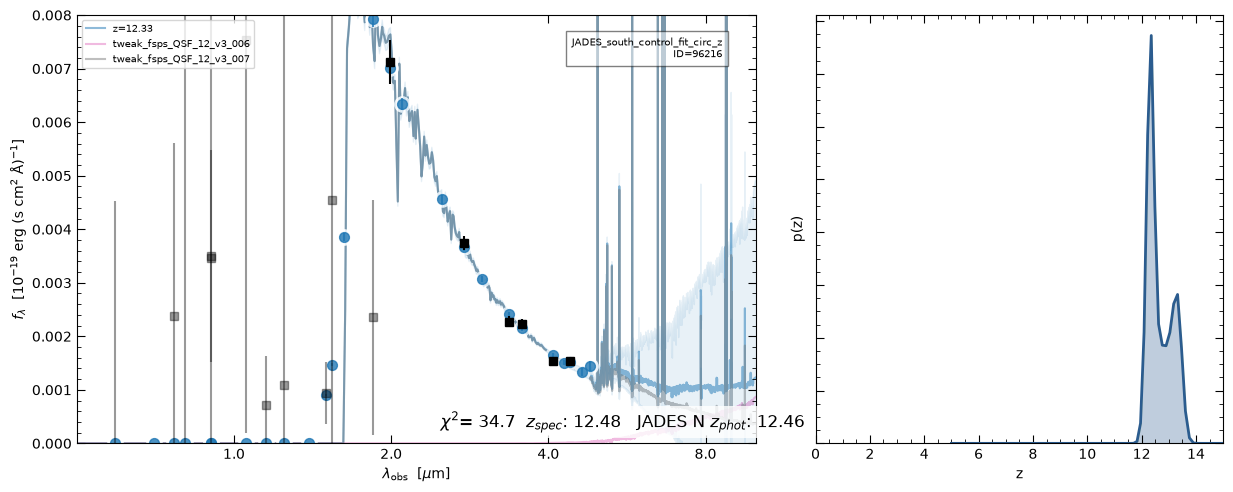

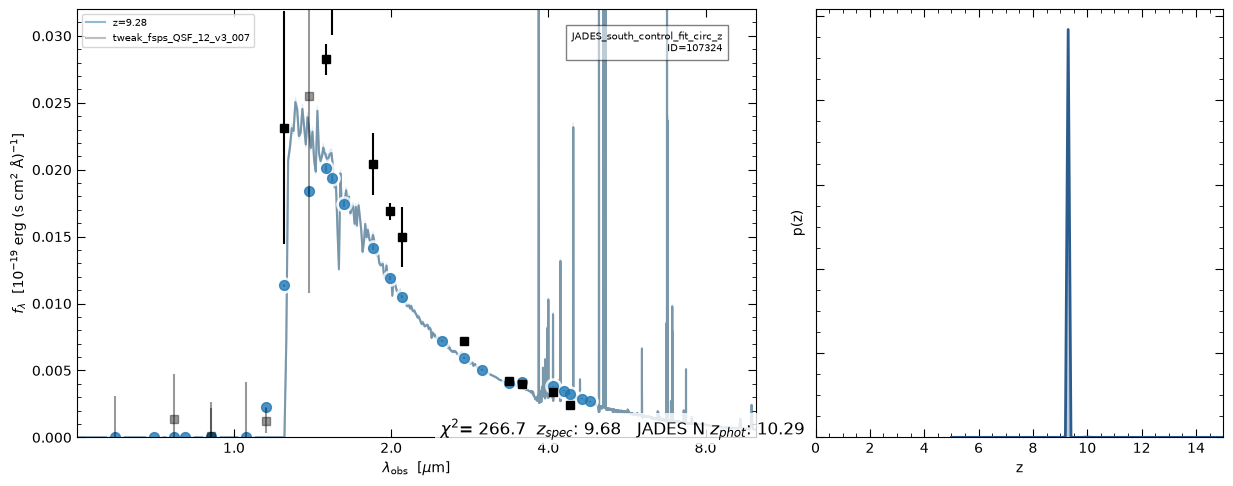

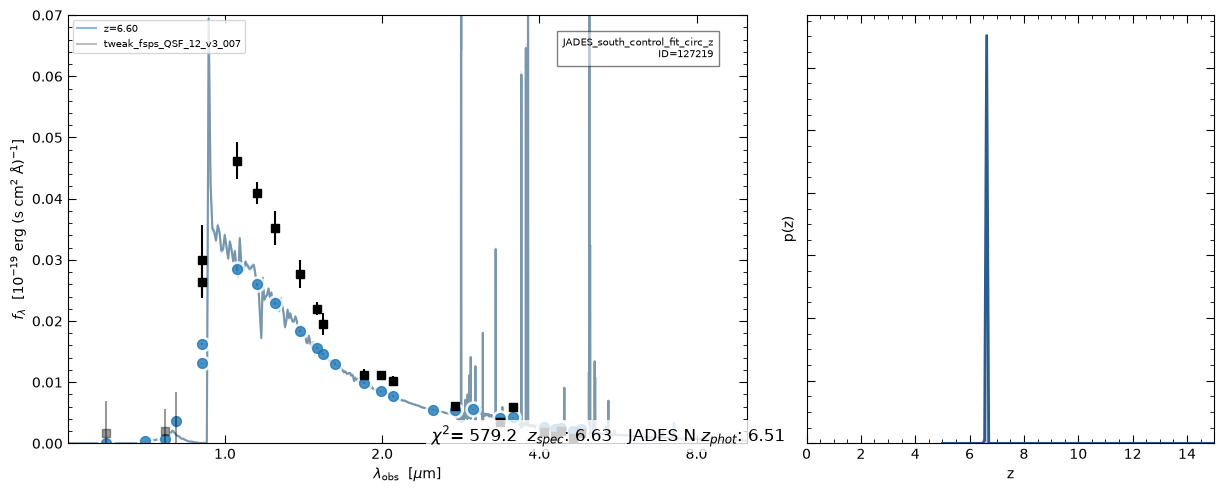

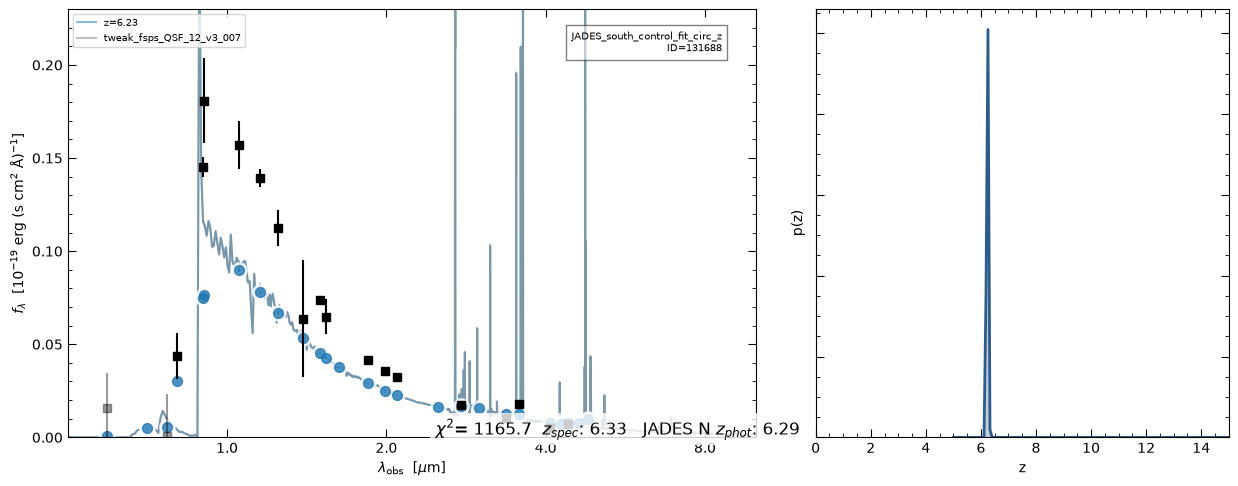

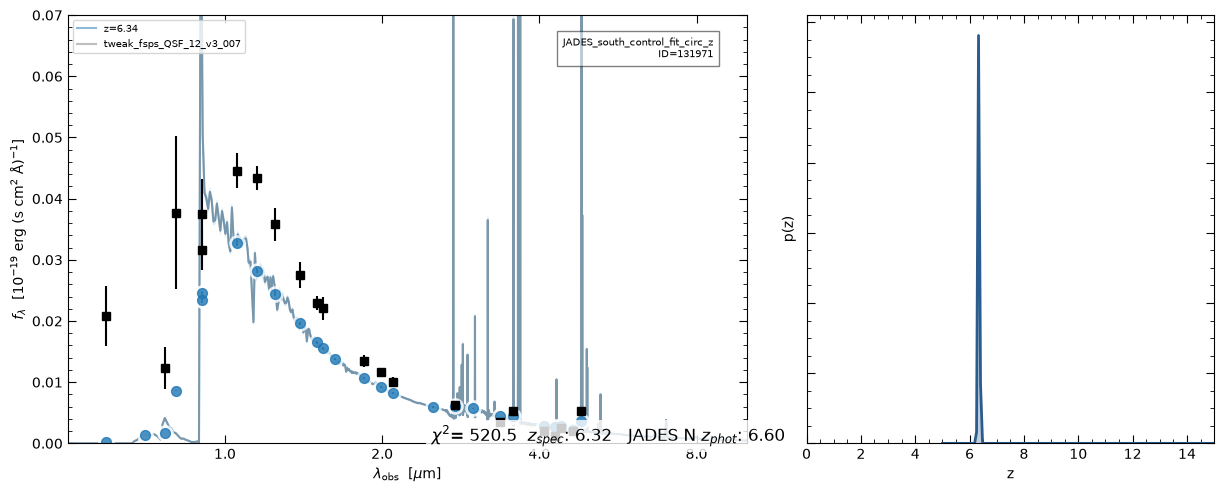

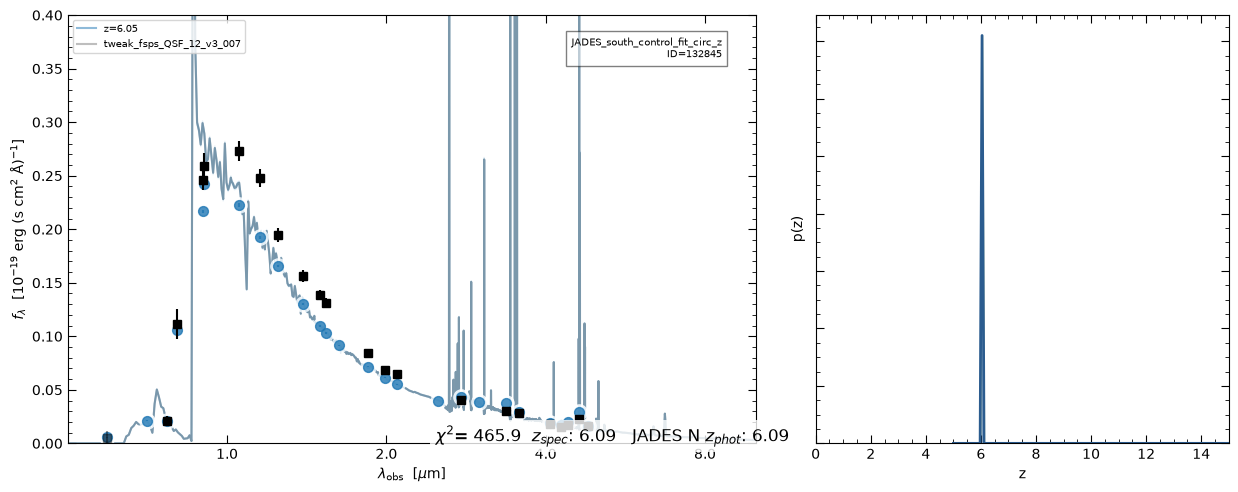

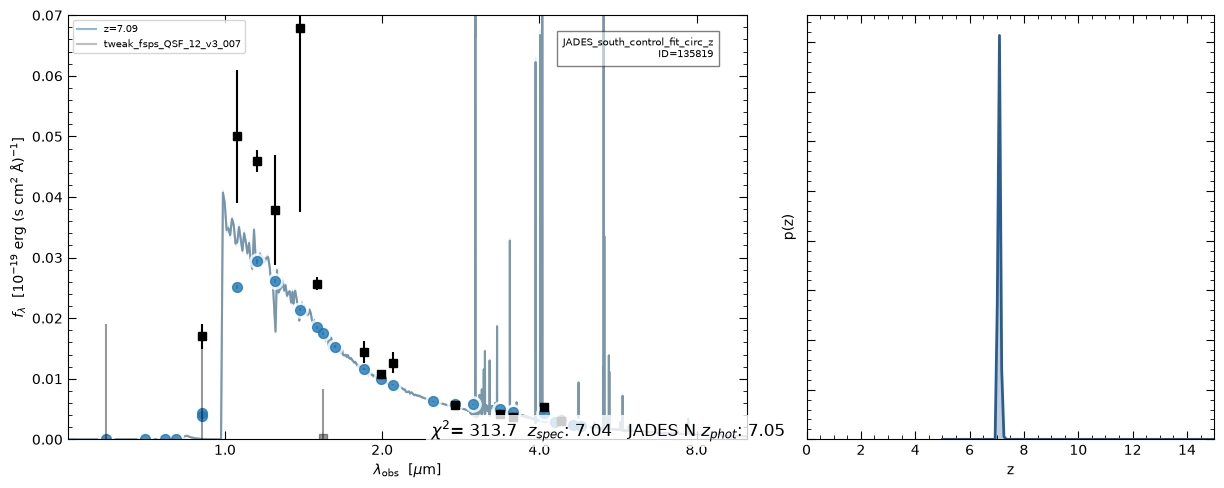

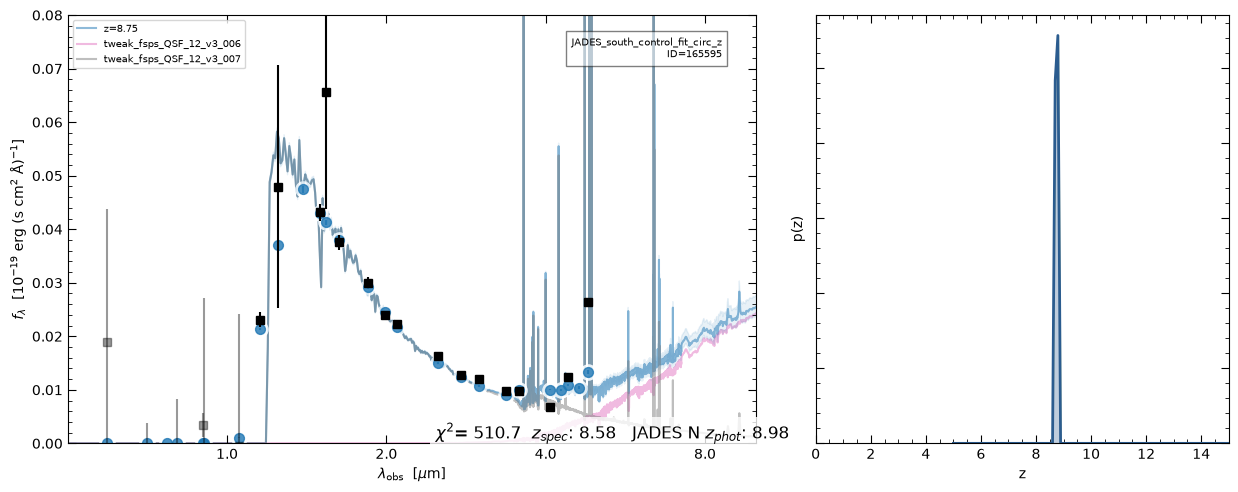

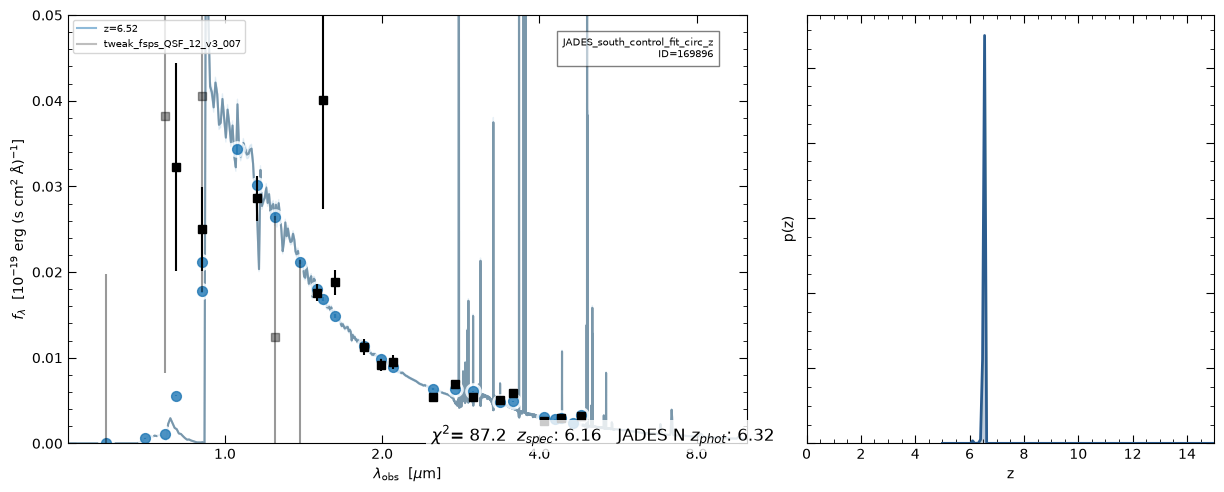

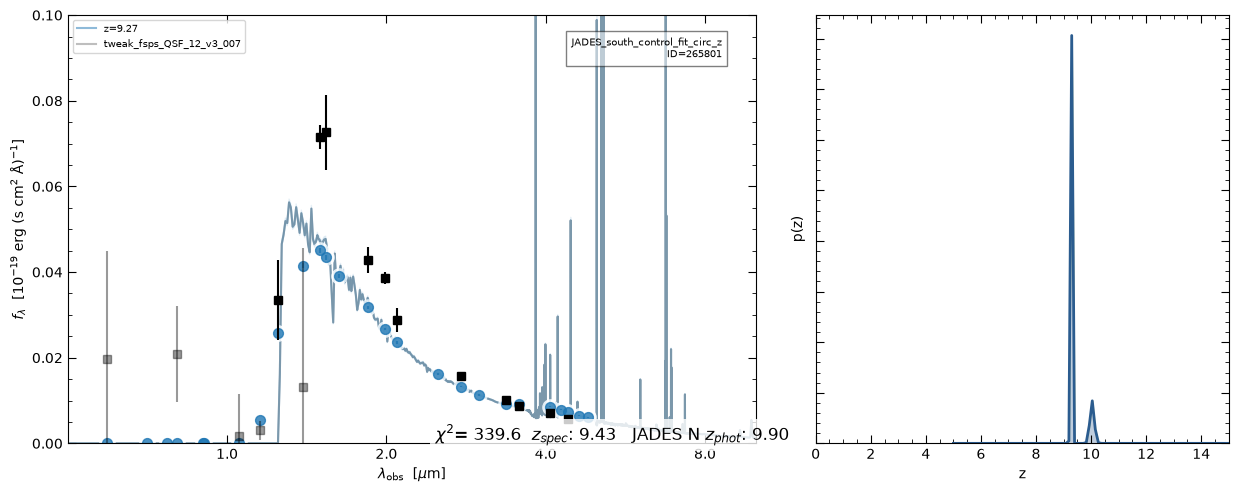

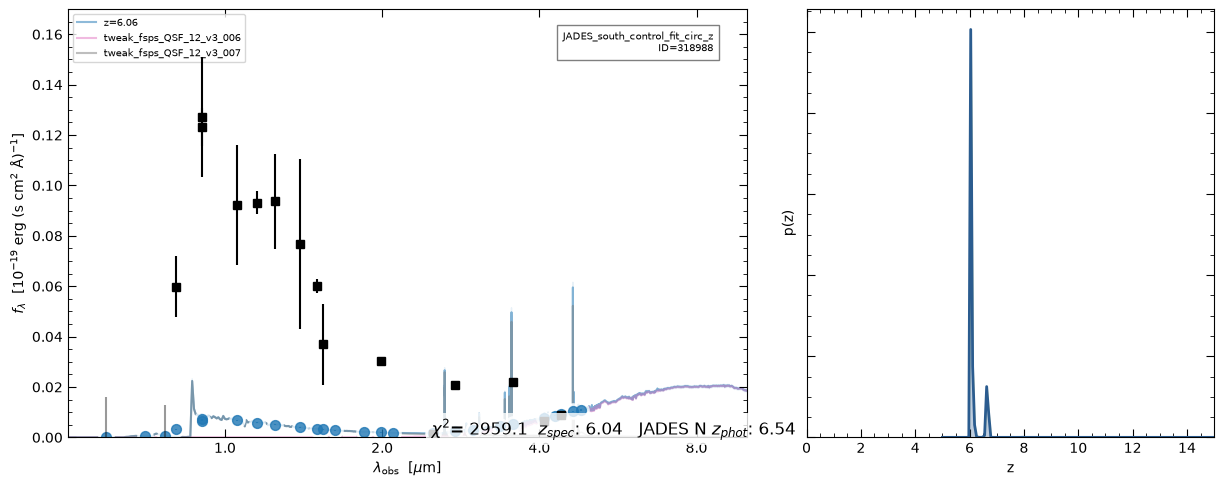

In [6]:
from matplotlib.ticker import AutoMinorLocator

output_path = '/home/caltech-msanche3/SURF2026/scripts/JADES scripts/Tweak Fitting/JADES_south_control_fit_circ_z.zout.fits'
output_data = Table.read(output_path)

ids_index = []
for i in range(len(ids)):
    n = np.where(zout['id']==ids[i])[0]
    ids_index.append(n.item())
print(ids_index)

ylims = [.22,.015,.12,.008,.032,.07,.23,.07,.4,.07,.08,.05,.1,.17]
for i in range(len(ids)):
    fig, data = ez.show_fit(ids[i], xlim=[.5, 10], show_components=True,
                            logpz=False, zr=[0,15])
    # grab ax & figs
    ax = plt.gca()
    fig = plt.gcf()
    
    fig.axes[0].set_ylim(0, ylims[i])

    # set size to be wider
    fig.set_size_inches(13, 5)
    
    # remove grid lines
    ax1 = fig.axes[0]
    ax2 = fig.axes[1]
    ax1.grid(False)
    ax2.grid(False)
    
    # change p(z)
    ax1 = fig.axes[1]
    for line in ax1.get_lines():
        line.set_color('#2b5c8f')   
        line.set_linewidth(2.0)     
    for collection in ax1.collections:
        collection.set_facecolor('#2b5c8f') 
        collection.set_alpha(0.3)          
    if ax1.get_legend():
        ax1.legend(frameon=False)

    for ax in fig.axes:
        ax.xaxis.set_minor_locator(AutoMinorLocator())
        ax.yaxis.set_minor_locator(AutoMinorLocator())
        
        ax.tick_params(
            axis='both', 
            which='both', 
            direction='in',  
            top=True,        
            right=True
        )
        
        ax.tick_params(axis='both', which='major', length=6)
        ax.tick_params(axis='both', which='minor', length=3)

    ax.text(x=-13.8, y=.06, s= "$\chi^2$= " f"{output_data[ids_index[i]]['z_phot_chi2']:.1f}  " r"$z_{spec}$: " f"{zspec[i]}   " r"JADES N $z_{phot}$: " f"{jades_zphot[i]:.2f}", 
            fontsize=12,
            color='k',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')) 

In [7]:
from spectres import spectres
import warnings
from scipy.interpolate import interp1d
warnings.filterwarnings('ignore')

paths = [
    '/home/caltech-msanche3/SURF2026/scripts/JADES scripts/south_spectra/jades_goods_south_13405.fits',
    '/home/caltech-msanche3/SURF2026/scripts/JADES scripts/south_spectra/jades_goods_south_14376.fits',
    '/home/caltech-msanche3/SURF2026/scripts/JADES scripts/south_spectra/jades_goods_south_27503.fits',
    '/home/caltech-msanche3/SURF2026/scripts/JADES scripts/south_spectra/jades_goods_south_96216.fits',
    '/home/caltech-msanche3/SURF2026/scripts/JADES scripts/south_spectra/jades_goods_south_107324.fits',
    '/home/caltech-msanche3/SURF2026/scripts/JADES scripts/south_spectra/jades_goods_south_127219.fits',
    '/home/caltech-msanche3/SURF2026/scripts/JADES scripts/south_spectra/jades_goods_south_131688.fits',
    '/home/caltech-msanche3/SURF2026/scripts/JADES scripts/south_spectra/jades_goods_south_131971.fits',
    '/home/caltech-msanche3/SURF2026/scripts/JADES scripts/south_spectra/jades_goods_south_132845.fits',
    '/home/caltech-msanche3/SURF2026/scripts/JADES scripts/south_spectra/jades_goods_south_135819.fits',
    '/home/caltech-msanche3/SURF2026/scripts/JADES scripts/south_spectra/jades_goods_south_165595.fits',
    '/home/caltech-msanche3/SURF2026/scripts/JADES scripts/south_spectra/jades_goods_south_169896.fits',
    '/home/caltech-msanche3/SURF2026/scripts/JADES scripts/south_spectra/jades_goods_south_265801.fits',
    '/home/caltech-msanche3/SURF2026/scripts/JADES scripts/south_spectra/jades_goods_south_318988.fits'
]
'''
ylims = [2.2,.15,1.2,.08,.32,.7,2.3,.7,4,.7,.8,.5,1,1.7]
nrmsers = []
for i in range(len(ids)):

    # generate model data
    sed_data = ez.show_fit(id=ids[i], get_spec=True, show_fnu=0,renorm_t=False)
    wave_model = sed_data['templz']/10000  # Observed frame wavelength (microns when divided by 1e4)
    flux_model=sed_data['templf']*10 # multiply times ten to make to units of 10^-20 erg/s/cm2/AA

    # generate observed data
    data = Table.read(paths[i])
    wave_obs = data['WAVELENGTH']
    #flux_obs = data['FLUX']
    flux_obs = data['FLUX']/1e-20 # make into units of 10^-20 erg/s/cm^2/AA
    err_obs = data['FLUX_ERR erg s-1 cm-2 AA-1']/1e-20 # make into units of 10^-20 erg/s/cm^2/AA

    # interpolate model to fit the wavelength array of the observed data
    flux_model_interp = spectres(
        wave_obs,                # Target wavelength
        wave_model,              # model wavelength grid
        flux_model,             #  model flux
        fill=np.nan,             # Fill value for out-of-bounds wavelengths
        verbose=False
    )

    # mask any value less than the lyman alpha drop off because it is different physics there
    mask = (wave_obs > (.1216*(1+zspec[i]))-.08)

    # calculate the reduced chi^2
    res = ((flux_obs[mask]-flux_model_interp[mask])/err_obs[mask]) ** 2
    chi2 = np.sum(res)/len(flux_obs[mask])
    print(chi2)

    fig,ax = plt.subplots(figsize=(10,6))

    ax.plot(wave_obs[mask],flux_obs[mask],alpha=.5)
    ax.plot(wave_obs[mask],flux_model_interp[mask],alpha=.5)

    ax.set_xlabel(r'$\lambda_{obs} \text{ }[\mu m]$')
    ax.set_ylabel(r'Flux [$10^{-20}$ erg $(s \text{ } cm^2 \text{ } \mathrm{\AA})^{-1}]$')

    ax.set_ylim(0,ylims[i])
    ax.set_title(f'45K Templates, ID: {ids[i]}, zspec: {zspec[i]}, Chi2: {chi2:1f}')
    ax.tick_params(axis='both', which='both', labelsize=10, direction='in', top=True, right=True)
    ax.grid(True, linestyle='--', alpha=0.5, linewidth=0.8, zorder=0)
    ax.legend(['Observed Spectrum','Reconstructed Spectrum'],loc='upper right')
    ax.minorticks_on()
'''

<>:61: SyntaxWarning: invalid escape sequence '\l'
<>:61: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1276652/205679887.py:61: SyntaxWarning: invalid escape sequence '\l'
  ax.set_xlabel(r'$\lambda_{obs} \text{ }[\mu m]$')


"\nylims = [2.2,.15,1.2,.08,.32,.7,2.3,.7,4,.7,.8,.5,1,1.7]\nnrmsers = []\nfor i in range(len(ids)):\n\n    # generate model data\n    sed_data = ez.show_fit(id=ids[i], get_spec=True, show_fnu=0,renorm_t=False)\n    wave_model = sed_data['templz']/10000  # Observed frame wavelength (microns when divided by 1e4)\n    flux_model=sed_data['templf']*10 # multiply times ten to make to units of 10^-20 erg/s/cm2/AA\n\n    # generate observed data\n    data = Table.read(paths[i])\n    wave_obs = data['WAVELENGTH']\n    #flux_obs = data['FLUX']\n    flux_obs = data['FLUX']/1e-20 # make into units of 10^-20 erg/s/cm^2/AA\n    err_obs = data['FLUX_ERR erg s-1 cm-2 AA-1']/1e-20 # make into units of 10^-20 erg/s/cm^2/AA\n\n    # interpolate model to fit the wavelength array of the observed data\n    flux_model_interp = spectres(\n        wave_obs,                # Target wavelength\n        wave_model,              # model wavelength grid\n        flux_model,             #  model flux\n        fill

In [7]:
import numpy as np
from scipy.integrate import cumulative_trapezoid
# 1. The redshift evaluation grid (1D array)
zgrid = ez.zgrid

# 2. Extract the log-likelihood array
# Shape is (NOBJ, NZ) where NOBJ is catalog size, NZ is length of zgrid
lnp = ez.lnp

# 3. Convert log-likelihood to likelihood probability distribution P(z)
# Shift by max(lnp) per object before exponentiating to avoid numerical underflow
p_z = np.exp(lnp - np.max(lnp, axis=1, keepdims=True))

# 4. Normalize P(z) so the integral over z equals 1
p_z_norm = p_z / np.trapezoid(p_z, zgrid, axis=1)[:, np.newaxis]

z_lo = []
z_hi = []
for i in range(len(ids_index)):
    cdf = cumulative_trapezoid(p_z_norm[ids_index][i], zgrid, initial=0)
    # Normalize CDF strictly to 1.0 just in case
    cdf /= cdf[-1]

    # 3. Interpolate to find the z values corresponding to the target percentiles
    z_16 = np.interp(0.16, cdf, zgrid)
    n = zout[ids_index][i]['z_phot'] - z_16
    z_lo.append(np.round(n,3).item())
    #z_50 = np.interp(0.50, cdf, zgrid)  # will use z_phot instead
    z_84 = np.interp(0.84, cdf, zgrid)
    n = z_84 - zout[ids_index][i]['z_phot']
    z_hi.append(np.round(n,3).item())

    #print(f"Redshift 16th percentile (z_16): {z_16:.3f}")
    #print(f"Chi^2 z_phot: {zout[ids_index][i]['z_phot']:.3f}")
    #print(f"Redshift 84th percentile (z_84): {z_84:.3f}")
    #print(f"1-sigma lower/upper bounds: z = {zout[ids_index][i]['z_phot']:.3f} +{z_84 - zout[ids_index][i]['z_phot']:.3f} -{zout[ids_index][i]['z_phot'] - z_16:.3f}")
    #print()
print(z_lo)
print(z_hi)
print(len(z_lo))


[0.075, 0.21, 0.081, 0.099, 0.057, 0.023, 0.047, 0.059, 0.056, 0.062, 0.08, 0.035, 0.039, 0.062]
[0.065, 0.074, 0.055, 0.905, 0.084, 0.081, 0.064, 0.048, 0.039, 0.07, 0.087, 0.077, 0.576, 0.116]
14


[7.966000080108643, 8.145999908447266, 8.069999694824219, 12.331999778747559, 9.282999992370605, 6.5980000495910645, 6.235000133514404, 6.340000152587891, 6.050000190734863, 7.090000152587891, 8.746000289916992, 6.520999908447266, 9.270999908447266, 6.064000129699707]
[[0.075, 0.21, 0.081, 0.099, 0.057, 0.023, 0.047, 0.059, 0.056, 0.062, 0.08, 0.035, 0.039, 0.062], [0.065, 0.074, 0.055, 0.905, 0.084, 0.081, 0.064, 0.048, 0.039, 0.07, 0.087, 0.077, 0.576, 0.116]]


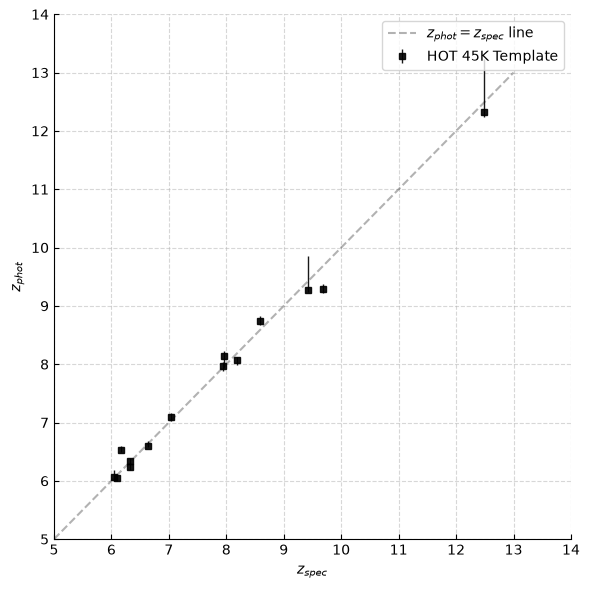

In [8]:
eazy_zphot = []
for i in range(len(ids_index)):
    n=output_data[ids_index[i]]['z_phot']
    eazy_zphot.append(np.round(n,3).item())
print(eazy_zphot)
err = [z_lo,z_hi]



fig,ax = plt.subplots(figsize=(6,6))
x = np.linspace(5,13,10)
y = np.linspace(5,13,10)
#ax.scatter(eazy_zphot,zspec,c='r',s=3)
print(err)

plt.errorbar(zspec, eazy_zphot, yerr=err, fmt='s',c='k',ms=5,elinewidth=1,alpha=0.9)
#ax.scatter(zspec,ceers_zphot,c='b',s=3)
#ax.scatter(zspec,ceers_zmed,c='b',s=3)
#plt.errorbar(zspec, ceers_zmed, yerr=ceers_err, fmt='s',c='b',ms=3,elinewidth=1,alpha=0.5)
ax.plot(x,y,alpha=0.3,c='k',linestyle='--')
ax.set_ylim(5,14)
ax.set_xlim(5,14)
ax.set_xlabel(r'$z_{spec}$')
ax.set_ylabel(r'$z_{phot}$')


ax.tick_params(axis='both', labelsize=10,direction='in')
ax.grid(True, linestyle='--', alpha=0.5, linewidth=0.8, zorder=0)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.legend([r'$z_{phot} = z_{spec}$ line',"HOT 45K Template"])
plt.tight_layout()